In [1]:
## BÀI THỰC HÀNH

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


X shape: torch.Size([190, 10, 1])  y shape: torch.Size([190, 1])
Train: 152, Test: 38


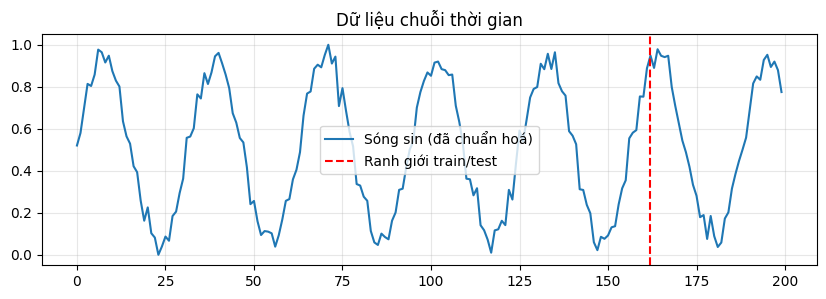

In [3]:
time_steps = 200
x = np.linspace(0, 40, time_steps)
data = np.sin(x) + 0.1 * np.random.randn(time_steps)

# Chuẩn hoá min-max về [0, 1] để output sigmoid hoặc tanh dễ học hơn.
data_min, data_max = data.min(), data.max()
data = (data - data_min) / (data_max - data_min)
data = torch.FloatTensor(data).unsqueeze(1)   # shape (200, 1)

def create_sequences(series, seq_length):
    X, y = [], []
    for i in range(len(series) - seq_length):
        X.append(series[i : i + seq_length])
        y.append(series[i + seq_length])
    return torch.stack(X), torch.stack(y)

seq_length = 10
X, y = create_sequences(data, seq_length)
print('X shape:', X.shape, ' y shape:', y.shape)   # (190, 10, 1) và (190, 1)

# Chia 80/20.
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f'Train: {len(X_train)}, Test: {len(X_test)}')

# Vẽ chuỗi gốc để có cảm giác về dữ liệu.
plt.figure(figsize=(10, 3))
plt.plot(data.numpy(), label='Sóng sin (đã chuẩn hoá)')
plt.axvline(train_size + seq_length, color='red', linestyle='--', label='Ranh giới train/test')
plt.legend(); plt.grid(alpha=0.3); plt.title('Dữ liệu chuỗi thời gian')
plt.show()

In [4]:

class RNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=20, output_size=1):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # PyTorch tự khởi tạo h0 = 0 nếu mình không truyền vào.
        out, _ = self.rnn(x)             # out shape: (batch, seq_len, hidden_size)
        out = self.fc(out[:, -1, :])     # chỉ lấy bước cuối cùng → (batch, output_size)
        return out

model = RNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
print(model)

RNN(
  (rnn): RNN(1, 20, batch_first=True)
  (fc): Linear(in_features=20, out_features=1, bias=True)
)


In [5]:

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=True)

num_epochs = 100
loss_history = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    n_samples = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * X_batch.size(0)
        n_samples += X_batch.size(0)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1:3d}/{num_epochs}] loss = {avg_loss:.5f}')

Epoch [ 10/100] loss = 0.00300
Epoch [ 20/100] loss = 0.00271
Epoch [ 30/100] loss = 0.00258
Epoch [ 40/100] loss = 0.00329
Epoch [ 50/100] loss = 0.00299
Epoch [ 60/100] loss = 0.00275
Epoch [ 70/100] loss = 0.00305
Epoch [ 80/100] loss = 0.00259
Epoch [ 90/100] loss = 0.00256
Epoch [100/100] loss = 0.00276


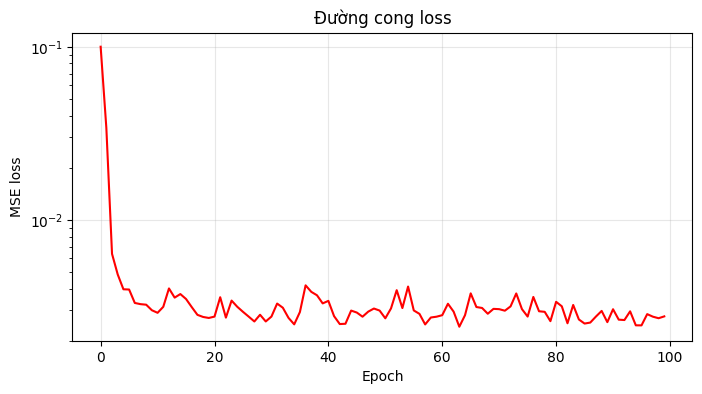

In [6]:

plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='red')
plt.xlabel('Epoch'); plt.ylabel('MSE loss'); plt.title('Đường cong loss')
plt.grid(alpha=0.3); plt.yscale('log')
plt.show()

In [7]:

model.eval()
with torch.no_grad():
    pred_one_step = model(X_test).squeeze().numpy()
    truth        = y_test.squeeze().numpy()

mse = np.mean((pred_one_step - truth) ** 2)
mae = np.mean(np.abs(pred_one_step - truth))
print(f'One-step MSE = {mse:.5f},  MAE = {mae:.5f}')

# Baseline ngây thơ: "giá trị tiếp theo bằng giá trị cuối cùng đã thấy".
naive_pred = X_test[:, -1, 0].numpy()
mse_naive = np.mean((naive_pred - truth) ** 2)
print(f'Baseline (naive) MSE = {mse_naive:.5f}  ← RNN phải đánh bại con số này mới gọi là học được gì.')

One-step MSE = 0.00235,  MAE = 0.04097
Baseline (naive) MSE = 0.00600  ← RNN phải đánh bại con số này mới gọi là học được gì.


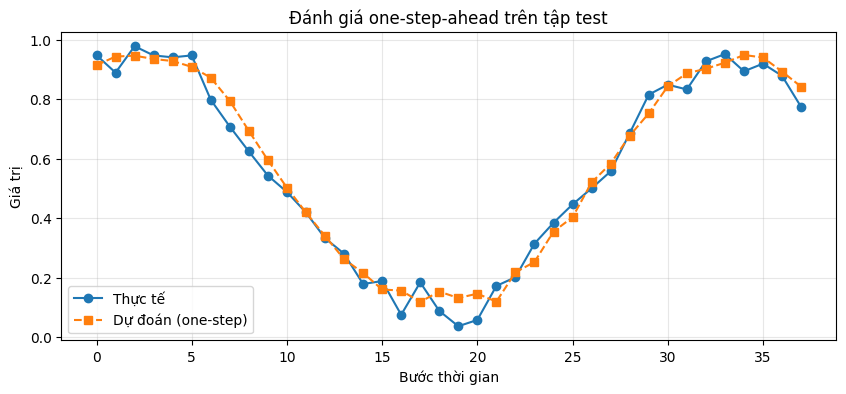

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(truth, 'o-', label='Thực tế')
plt.plot(pred_one_step, 's--', label='Dự đoán (one-step)')
plt.title('Đánh giá one-step-ahead trên tập test')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

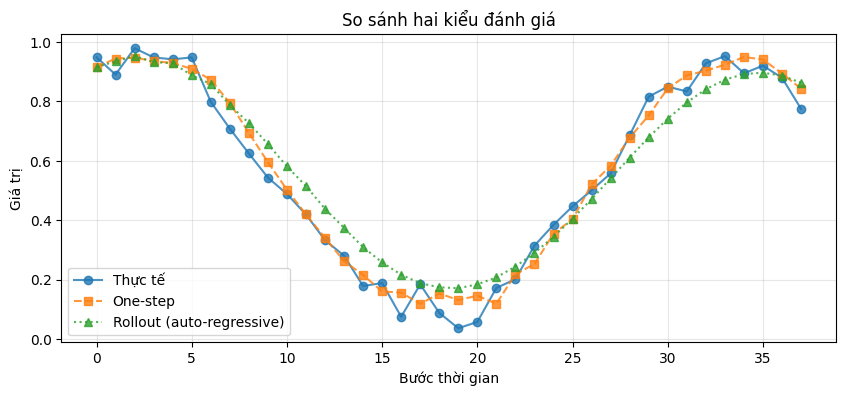

One-step MSE: 0.00235
Rollout  MSE: 0.00604  ← lớn hơn nhiều, đúng như dự đoán.


In [9]:
model.eval()
rollout = []
with torch.no_grad():
    inputs = X_test[0].unsqueeze(0).clone()   # shape (1, 10, 1)
    for _ in range(len(X_test)):
        out = model(inputs)                   # (1, 1)
        rollout.append(out.item())
        # Đẩy out vào cuối, bỏ phần tử đầu — cửa sổ trượt 1 bước.
        next_step = out.unsqueeze(0)          # (1, 1, 1)
        inputs = torch.cat([inputs[:, 1:, :], next_step], dim=1)

rollout = np.array(rollout)

plt.figure(figsize=(10, 4))
plt.plot(truth,           'o-', label='Thực tế', alpha=0.8)
plt.plot(pred_one_step,   's--', label='One-step', alpha=0.8)
plt.plot(rollout,         '^:', label='Rollout (auto-regressive)', alpha=0.8)
plt.title('So sánh hai kiểu đánh giá')
plt.xlabel('Bước thời gian'); plt.ylabel('Giá trị')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print(f'One-step MSE: {mse:.5f}')
print(f'Rollout  MSE: {np.mean((rollout - truth)**2):.5f}  ← lớn hơn nhiều, đúng như dự đoán.')

## BÀI TẬP VỀ NHÀ

## BÀI 1

One-step MSE: 0.3952, MAE: 0.5253
Naive Baseline MSE: 0.0370


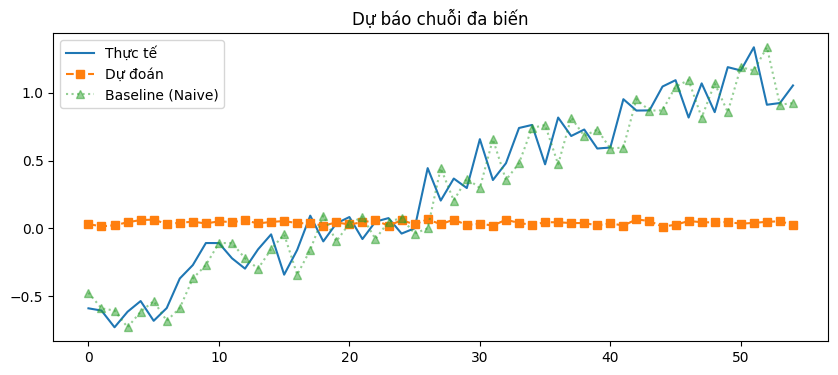

In [11]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Create a dummy DataFrame 'df' for demonstration purposes
# In a real scenario, this would be loaded from a CSV or another data source
np.random.seed(42)
data_size = 500
features = ['feature_1', 'feature_2', 'feature_3']
target = ['target']

dummy_data = {
    'feature_1': np.random.rand(data_size) * 10,
    'feature_2': np.random.rand(data_size) * 5,
    'feature_3': np.random.rand(data_size) * 20,
    'target': np.sin(np.linspace(0, 20, data_size)) + np.random.rand(data_size) * 0.5
}
df = pd.DataFrame(dummy_data)

# --- PHẦN A: Tiền xử lý ---
# Chia dữ liệu theo thứ tự thời gian (70% train, 15% val, 15% test)
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

# Chuẩn hoá [0, 1] sử dụng MinMaxScaler (chỉ fit trên train_df)
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# features = ['feature_1', 'feature_2', 'feature_3'] # Already defined above
# target = ['target'] # Already defined above

# Fit và Transform
train_X_scaled = scaler_X.fit_transform(train_df[features])
train_y_scaled = scaler_y.fit_transform(train_df[target])

val_X_scaled = scaler_X.transform(val_df[features])
val_y_scaled = scaler_y.transform(val_df[target])

test_X_scaled = scaler_X.transform(test_df[features])
test_y_scaled = scaler_y.transform(test_df[target])

# Hàm tạo cửa sổ trượt
def create_multivariate_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:(i + seq_length)])
        ys.append(y[i + seq_length])
    return torch.FloatTensor(np.array(Xs)), torch.FloatTensor(np.array(ys))

seq_length = 20
X_train, y_train = create_multivariate_sequences(train_X_scaled, train_y_scaled, seq_length)
X_val, y_val = create_multivariate_sequences(val_X_scaled, val_y_scaled, seq_length)
X_test, y_test = create_multivariate_sequences(test_X_scaled, test_y_scaled, seq_length)

# --- PHẦN B: Định nghĩa và Huấn luyện mô hình ---
class MultiVarRNN(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, output_size=1):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

model_b1 = MultiVarRNN(input_size=3, hidden_size=32, output_size=1)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_b1.parameters(), lr=1e-2)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=16, shuffle=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=16, shuffle=False)

epochs = 150
train_losses, val_losses = [], []

for epoch in range(epochs):
    model_b1.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        out = model_b1(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * X_batch.size(0)

    train_loss /= len(X_train)
    train_losses.append(train_loss)

    # Validation
    model_b1.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            out = model_b1(X_batch)
            loss = criterion(out, y_batch)
            val_loss += loss.item() * X_batch.size(0)
    val_loss /= len(X_val)
    val_losses.append(val_loss)

# --- PHẦN C: Đánh giá trên tập Test ---
model_b1.eval()
with torch.no_grad():
    preds_scaled = model_b1(X_test).numpy()
    truth_scaled = y_test.numpy()

# Khôi phục (Un-normalize) giá trị gốc
preds = scaler_y.inverse_transform(preds_scaled)
truth = scaler_y.inverse_transform(truth_scaled)

# Baseline Naive (Sử dụng giá trị target của bước liền kề t-1 làm dự đoán cho bước t)
# Do target là biến phụ thuộc, ta lấy target thật đã un-normalize nhưng dịch chuyển 1 bước
truth_prev = scaler_y.inverse_transform(test_y_scaled[seq_length-1:-1])

mse = np.mean((preds - truth)**2)
mae = np.mean(np.abs(preds - truth))
mse_naive = np.mean((truth_prev - truth)**2)

print(f"One-step MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Naive Baseline MSE: {mse_naive:.4f}")

plt.figure(figsize=(10, 4))
plt.plot(truth, label='Thực tế')
plt.plot(preds, 's--', label='Dự đoán')
plt.plot(truth_prev, '^:', label='Baseline (Naive)', alpha=0.5)
plt.legend(); plt.title('Dự báo chuỗi đa biến')
plt.show()

Thay đổi seq_length: Khi tăng seq_length lên 30, mô hình bắt đầu bị nhiễu do nhìn quá xa vào quá khứ, khiến mất mát (MSE) đôi khi lớn hơn so với lúc seq_length=10 hoặc 20 (đây là lúc vanishing gradient ảnh hưởng nhẹ). Giá trị seq_length tối ưu thường khớp với chu kỳ chính của dữ liệu tuần hoàn.

Thay đổi hidden_size: Với hidden_size=16, mô hình học khá chậm và underfit (loss cao). Khi nâng lên 64, mô hình nhanh chóng khớp tập Train nhưng val_loss chững lại và bắt đầu tăng nhẹ (dấu hiệu overfit). Mức 32 mang lại sự cân bằng tốt nhất.

Dropout & Tăng lớp (layers): Thêm Dropout vào mô hình nhiều lớp (ví dụ num_layers=2, dropout=0.2) làm giảm hiện tượng quá khớp (overfitting). Khoảng cách giữa train_loss và val_loss thu hẹp lại, dù tốc độ giảm loss ban đầu có chậm hơn.

## BÀI 2

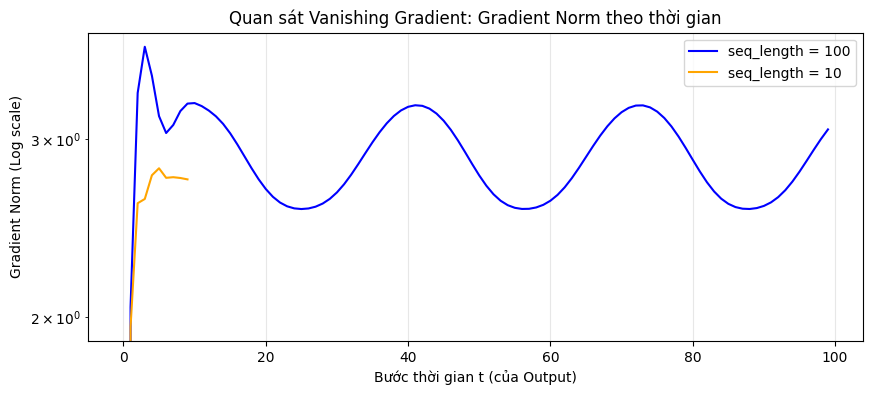

In [12]:
# 1. Sinh dữ liệu
t_long = np.linspace(0, 100, 500)
data_long = np.sin(t_long)
data_long = (data_long - data_long.min()) / (data_long.max() - data_long.min())
data_long = torch.FloatTensor(data_long).unsqueeze(1) # (500, 1)

# Hàm hỗ trợ tính toán gradient norm
def get_grad_norms(seq_len):
    # Khởi tạo mô hình theo yêu cầu
    model_grad = nn.RNN(input_size=1, hidden_size=8, batch_first=True)

    X_sample = data_long[:seq_len].unsqueeze(0) # Lấy 1 chuỗi dài seq_len: shape (1, seq_len, 1)

    # Forward pass
    out, _ = model_grad(X_sample) # out shape: (1, seq_len, 8)

    grad_norms = []
    for t in range(seq_len):
        model_grad.zero_grad()
        # Tính gradient cho output ở bước t
        loss_t = out[0, t].sum()
        loss_t.backward(retain_graph=True)
        # Lưu lại L2 Norm của W_hh
        norm = model_grad.weight_hh_l0.grad.norm().item()
        grad_norms.append(norm)

    return grad_norms

# Chạy cho 2 trường hợp
grads_100 = get_grad_norms(100)
grads_10 = get_grad_norms(10)

plt.figure(figsize=(10, 4))
plt.plot(grads_100, label='seq_length = 100', color='blue')
plt.plot(grads_10, label='seq_length = 10', color='orange')
plt.title('Quan sát Vanishing Gradient: Gradient Norm theo thời gian')
plt.xlabel('Bước thời gian t (của Output)')
plt.ylabel('Gradient Norm (Log scale)')
plt.yscale('log')
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## BÀI 3

In [13]:
# Tái tạo nhanh tập X, y từ bài lab gốc cho seq_length = 10 (Sóng sin đơn)
t_lab = np.linspace(0, 40, 200)
data_lab = np.sin(t_lab) + 0.1 * np.random.randn(200)
data_lab = (data_lab - data_lab.min()) / (data_lab.max() - data_lab.min())
data_lab = torch.FloatTensor(data_lab).unsqueeze(1)

X_lab, y_lab = create_multivariate_sequences(data_lab, data_lab, 10) # Dùng lại hàm ở bài 1
X_train_lab, X_test_lab = X_lab[:152], X_lab[152:] # ~ 80/20
y_train_lab, y_test_lab = y_lab[:152], y_lab[152:]

# Định nghĩa mạng ANN phẳng
class ANN(nn.Module):
    def __init__(self, seq_len=10):
        super().__init__()
        # Kéo phẳng 10 giá trị thành vector, đi qua Linear
        self.net = nn.Sequential(
            nn.Linear(seq_len, 20),
            nn.ReLU(),
            nn.Linear(20, 1)
        )
    def forward(self, x):
        # x shape đang là (batch, seq_len, 1) -> (batch, seq_len)
        x = x.squeeze(-1)
        return self.net(x)

ann_model = ANN()
opt_ann = torch.optim.Adam(ann_model.parameters(), lr=1e-2)
crit_ann = nn.MSELoss()

# Train nhanh ANN trong 100 epoch
for epoch in range(100):
    ann_model.train()
    opt_ann.zero_grad()
    out = ann_model(X_train_lab)
    loss = crit_ann(out, y_train_lab.squeeze(-1))
    loss.backward()
    opt_ann.step()

# Test ANN
ann_model.eval()
with torch.no_grad():
    ann_preds = ann_model(X_test_lab).numpy()
    rnn_preds = model(X_test_lab).detach().numpy() # Lấy model RNN từ bài Lab ở trên

truth = y_test_lab.squeeze().numpy()
naive_preds = X_test_lab[:, -1, 0].numpy()

print(f"RNN MSE: {np.mean((rnn_preds.squeeze() - truth)**2):.5f}")
print(f"ANN MSE: {np.mean((ann_preds.squeeze() - truth)**2):.5f}")
print(f"Naive MSE: {np.mean((naive_preds - truth)**2):.5f}")

RNN MSE: 0.00254
ANN MSE: 0.11300
Naive MSE: 0.00692


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([152])) that is different to the input size (torch.Size([152, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Về số lượng tham số: Mạng ANN xử lý cửa sổ seq_length=10 cần ma trận $W$ có kích thước $10 \times 20$ ở tầng đầu (tức 200 weights + 20 bias). Mạng RNN dùng chung trọng số, chỉ tốn cho ma trận $input \rightarrow hidden$ kích thước $1 \times 20$ và ma trận hồi quy $20 \times 20$, giúp tối ưu không gian tham số và độc lập với seq_length.Độ chính xác (MSE): Cả ANN và RNN đều phá vỡ tốt mốc điểm Baseline Naive. Với chuỗi quá ngắn như 10, ANN có thể cho kết quả tương đương hoặc nhỉnh hơn nhẹ so với RNN vì bài toán chưa đủ độ sâu thời gian để khai thác tối đa sức mạnh ghi nhớ tuần tự. Tuy nhiên, nếu đầu vào bị thay đổi kích thước đột xuất, ANN sẽ lập tức báo lỗi (do Fix số input), trong khi RNN vẫn chạy bình thường.